<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

# type hints
from typing import List, Tuple
from collections import defaultdict

In [ ]:
def gray(r: float, g: float, b: float) -> float:
  return (0.2989 * r + 0.5870 * g + 0.1140 * b)

def grayscale(image: np.ndarray) -> np.ndarray:
  # This version is slow because of loops
  # height, width, channels = image.shape

  # grayImg = np.zeros((height, width), dtype=np.uint8)

  # for i in range(height):
  #   for j in range(width):
  #     r, g, b = image[i, j]
  #     grayVal = gray(r, g, b)
  #     grayImg[i, j] = grayVal

  # return grayImg

  # vectorized version
  return gray(image[:, :, 0], image[:, :, 1], image[:, :, 2]).astype(np.uint8)

In [ ]:
def read(filepaths: List[str], mode: str) -> defaultdict[np.ndarray]:
  validModes = ["gray", "color"]
  if mode not in validModes: return ValueError(f"Not valid image mode, valid modes: {validModes}")

  images = []

  if mode == "color":
    for filepath in filepaths:
      try:
        image = cv.imread(filepath)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        images.append(image)
      except Exception as e:
        return ValueError(f"Unknown error occured: {e}")
      except FileNotFoundError:
        return ValueError(f"Not valid filepath: {filepath}")
  elif mode == "gray":
    for filepath in filepaths:
      try:
        image = cv.imread(filepath)
        grayImg = grayscale(image)
        images.append(grayImg)
      except Exception as e:
        return ValueError(f"Unknown error occured: {e}")
      except FileNotFoundError:
        return ValueError(f"Not valid filepath: {filepath}")

  return images

In [ ]:
def show(image: np.ndarray, cmap=None, title=None):
  try:
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
  except Exception as e:
    return ValueError(f"Unknown error occured: {e}")

In [ ]:
commonPath = "/content"
grayFilePaths = [
    #f"{commonPath}/food_3.jpg",
    f"{commonPath}/dog_1.jpg",
    f"{commonPath}/dog_2.jpg"
    # f"{commonPath}/test_1.png",
    # f"{commonPath}/test_2.png"
]

grayImages = read(grayFilePaths, "gray")

burger = grayImages[0]

a = grayImages[0]
b = grayImages[1]

height, width = b.shape

if a.shape != b.shape:
  a = cv.resize(a, (height, width))

In [ ]:
colorFilePaths = [
    f"{commonPath}/burger.jpg"
]

colorImages = read(colorFilePaths, "color")
colorBurger = colorImages[0]

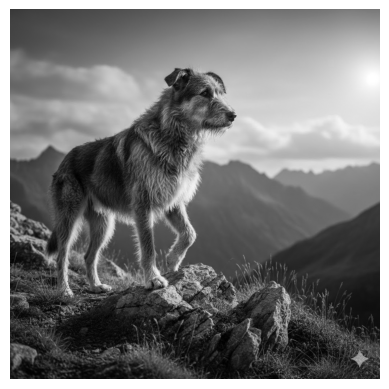

In [ ]:
show(a, cmap="gray")

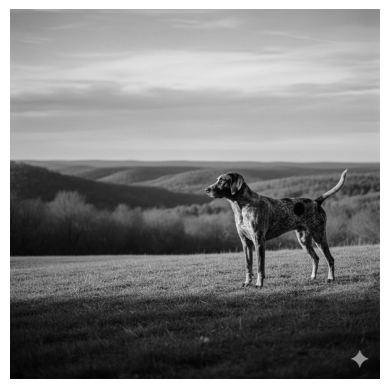

In [ ]:
show(b, cmap="gray")

In [ ]:
# emee filter function
def filter(Imax: float, Imin: float, alpha: float, c: float) -> float:
  r = Imax / (Imin + c)
  # # avoids log(0)
  r = max(r, 1)
  return alpha * (r ** alpha) * np.log(r)

def divideBlock(image: np.ndarray, k1: int, k2: int) -> List[np.ndarray]:
  if image is None:
    print(f"Not valid image")
    return

  height, width = image.shape

  blockHeight = height // k1
  blockWidth = width // k2

  blocks = []

  for i in range(k1):
    for j in range(k2):
      block = image[i * blockHeight: (i + 1) * blockHeight, j * blockWidth: (j + 1) * blockWidth]
      blocks.append(block)

  return blocks

def EMEE(image: np.ndarray, alpha: float, k1: int, k2: int, c: float) -> float:
  quality = 0
  blocks = divideBlock(image, k1, k2)

  blockSize = k1 * k2

  # This version uses too many loops
  # for i in range(blockSize):
  #   Imax = math.float('-inf')
  #   Imin = math.float('inf')

  #   for h in range(len(blocks[i])):
  #     for j in range(len(blocks[i][h])):
  #       Imax = max(Imax, blocks[i][h][j])
  #       Imin = min(Imin, blocks[i][h][j])

  #   quality += filter(Imax, Imin, alpha, c)

  for block in blocks:
    Imax = np.max(block)
    Imin = np.min(block)
    quality += filter(Imax, Imin, alpha, c)

  return (1 / blockSize) * quality

alpha = 0.9
k1, k2 = 4, 4
c = 1

quality = EMEE(burger, alpha, k1, k2, c)
quality

np.float64(403.39884597882497)

In [ ]:
# helper function to convert to graytone or vice versa
M = 255.0
epsilon = 1e-6

def grayToneCvt(g: np.ndarray) -> np.ndarray:
    g = g.astype(np.float32)
    return np.clip(M - g, 0, M - epsilon)

def grayLevelCvt(tone):
    return np.clip(M - tone, 0, M - epsilon)

In [ ]:
def lipAdd(a: np.ndarray, b: np.ndarray) -> np.ndarray:
  a = a.astype(np.float32)
  b = b.astype(np.float32)

  return (a + b - ((a * b) / M))

logAdd = grayLevelCvt(lipAdd(grayToneCvt(a), grayToneCvt(b)))

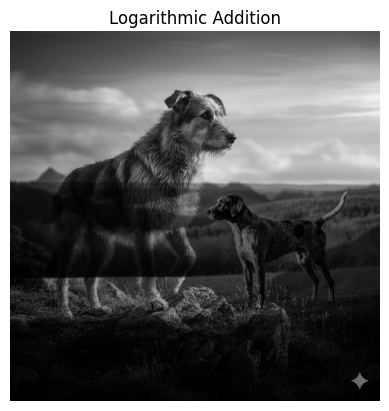

In [ ]:
show(logAdd, cmap="gray", title="Logarithmic Addition")

In [ ]:
EMEE(logAdd, alpha, k1, k2, c)

np.float32(328.45602)

In [ ]:
def lipSub(a_tone, b_tone, M=255.0):
    denom = np.maximum(M - b_tone, 1e-7)
    res = M * ((a_tone - b_tone) / denom)
    return np.clip(res, 0, M)

logSub = grayLevelCvt(lipSub(grayToneCvt(b), grayToneCvt(a)))

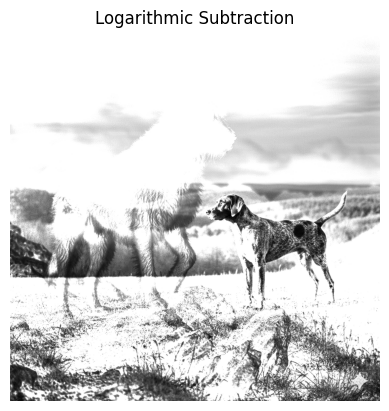

In [ ]:
show(logSub, cmap="gray", title="Logarithmic Subtraction")

In [ ]:
EMEE(logSub, alpha, k2, k2, c)

np.float32(247.74991)

In [ ]:
def lipMult(a: np.ndarray, b: np.ndarray) -> np.ndarray:
  def phi(a: np.ndarray) -> float:
    a = a.astype(np.float32)
    val = 1 - (a / M)
    return -M * np.log(np.maximum(val, epsilon))

  def phiInv(a: np.ndarray) -> float:
    a = a.astype(np.float32)
    return M * (1 - np.exp(- a / M))

  return phiInv(phi(a) * phi(b))

logMult = grayLevelCvt(lipMult(grayToneCvt(a), grayToneCvt(b)))

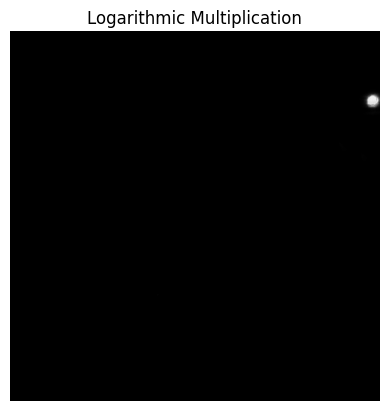

In [ ]:
show(logMult, cmap="gray", title="Logarithmic Multiplication")

In [ ]:
EMEE(logMult, alpha, k1, k2, c)

np.float64(40.07071307301521)

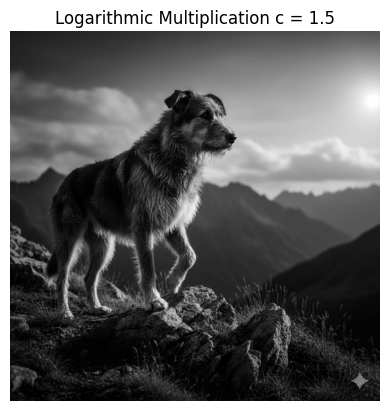

In [ ]:
def scalarLipMult(a: np.ndarray, c: float) -> np.ndarray:
  a = a.astype(np.float32)
  return M - M * ((1 - a / M) ** c)

constant = 1.5
scalarMult = grayLevelCvt(scalarLipMult(grayToneCvt(a), constant))
show(scalarMult, cmap="gray", title=f"Logarithmic Multiplication c = {constant}")

In [ ]:
EMEE(scalarMult, alpha=0.9, k1=4, k2=4, c=1)

np.float32(440.93823)

In [ ]:
def RGB(image: np.ndarray) -> np.ndarray:
  red = image[:, :, 0]
  green = image[:, :, 1]
  blue = image[:, :, 2]
  return (red, green, blue)

def getRGBComponents(red: np.ndarray, green: np.ndarray, blue: np.ndarray) -> List[np.ndarray]:
  redZeros = np.zeros_like(red)
  redImg = np.stack([red, redZeros, redZeros], axis=2)

  greenZeros = np.zeros_like(green)
  greenImg = np.stack([greenZeros, green, greenZeros], axis=2)

  blueZeros = np.zeros_like(blue)
  blueImg = np.stack([blueZeros, blueZeros, blue], axis=2)

  return (redImg, greenImg, blueImg)

red, green, blue = RGB(colorBurger)
redImg, greenImg, blueImg = getRGBComponents(red, green, blue)

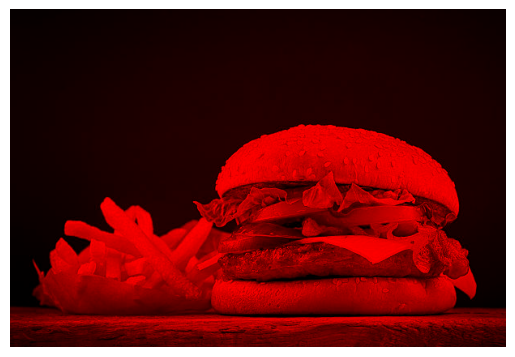

In [ ]:
show(redImg)

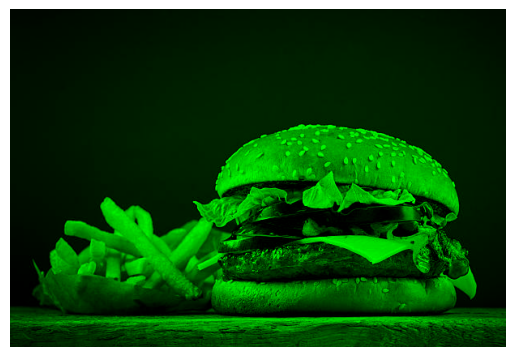

In [ ]:
show(greenImg)

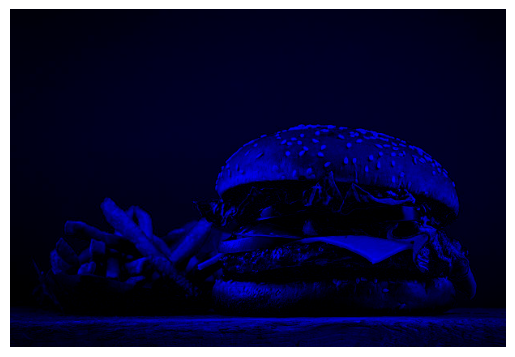

In [ ]:
show(blueImg)

In [ ]:
def HSV(image_hsv: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    h = image_hsv[:, :, 0]
    s = image_hsv[:, :, 1]
    v = image_hsv[:, :, 2]
    return (h, s, v)

def getHSVComponents(h, s, v):
  return (h / 360.0, s / 100.0, v / 100.0)

In [ ]:
def RGB2HSV(image: np.ndarray):
  height, width, channels = image.shape
  hsvImage = np.zeros((height, width, channels), dtype=np.float32)

  for i in range(height):
    for j in range(width):
      r, g, b = image[i, j]

      # convert to h, s, v values Source: https://www.w3resource.com/python-exercises/math/python-math-exercise-77.php
      r, g, b = r / 255.0, g / 255.0, b / 255.0
      mx = max(r, g, b)
      mn = min(r, g, b)
      df = mx - mn
      if mx == mn:
          h = 0
      elif mx == r:
          h = (60 * ((g - b) / df) + 360) % 360
      elif mx == g:
          h = (60 * ((b - r) / df) + 120) % 360
      elif mx == b:
          h = (60 * ((r - g) / df) + 240) % 360
      if mx == 0:
          s = 0
      else:
          s = (df / mx) * 100
      v = mx * 100

      hsvImage[i, j] = [h, s, v]

  return hsvImage

hsvBurger = RGB2HSV(colorBurger)

h, s, v = HSV(hsvBurger)
hDisp, sDisp, vDisp = getHSVComponents(h, s, v)

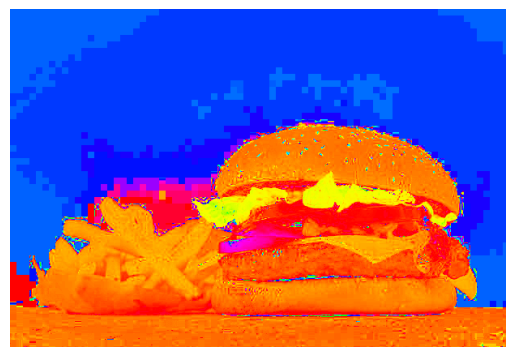

In [ ]:
show(hDisp, cmap="hsv")

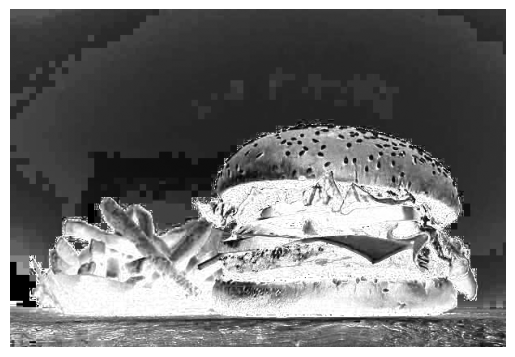

In [ ]:
show(sDisp, cmap="gray")

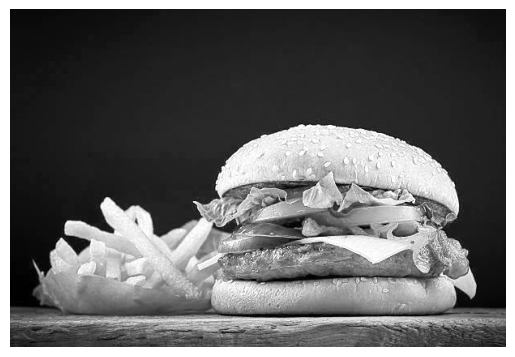

In [ ]:
show(vDisp, cmap="gray")

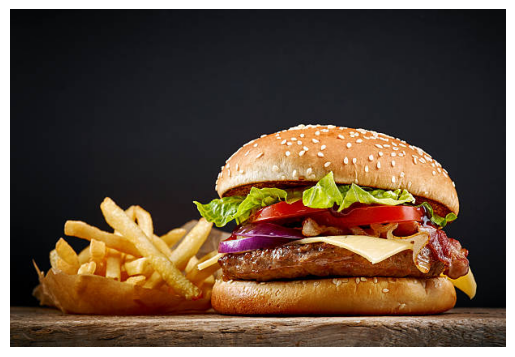

In [ ]:
show(colorBurger)

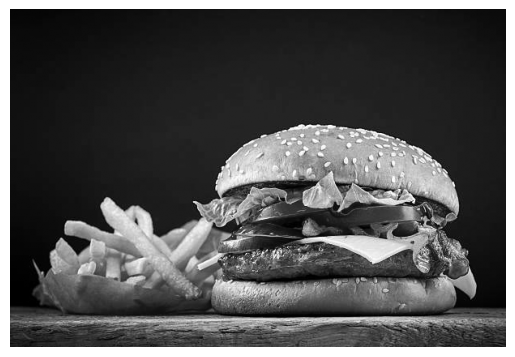

In [ ]:
colorToGray = grayscale(colorBurger)
show(colorToGray, cmap="gray")